In [1]:
from weather_engine.database import engine
import pandas as pd
import xgboost as xgb
from weather_engine.llocv import load_fold, temporal_split_fold


FEATURES = ['rain', 'ws', 'td', 'rh', 'tdmax', 'tdmin', 'u_vec', 'v_vec']

station_neighbors: pd.DataFrame = pd.read_sql("SELECT * FROM station_neighbors", engine)

In [3]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

all_X = []
all_y = []

all_data = pd.read_sql("SELECT * FROM clean_station_data", engine)
all_data['timestamp'] = pd.to_datetime(all_data['timestamp'])
all_data = all_data.set_index('timestamp').sort_index()
station_frames = {sid: grp.drop(columns='station_id') 
                  for sid, grp in all_data.groupby('station_id')}

for _, row in station_neighbors.iterrows():
    X, y = load_fold(
        int(row["station_id"]),
        int(row["neighbor_1_id"]),
        int(row["neighbor_2_id"]), 
        int(row["neighbor_3_id"]),
        station_frames=station_frames
    )
    all_X.append(X)
    all_y.append(y)
print("All folds loaded.")


all_X = pd.concat(all_X).sort_index()
all_y = pd.concat(all_y).sort_index()

X_train, X_val, y_train, y_val = temporal_split_fold(all_X, all_y)

models = {}
errors = {}

for feature in FEATURES:
    print(f"[{FEATURES.index(feature) + 1}/{len(FEATURES)}] Training RFSI for '{feature}'...", end=' ')
    if feature == 'rain':
        model = xgb.XGBRegressor(n_jobs=-1, objective='reg:tweedie', tweedie_variance_power=1.5)
    else:
        model = xgb.XGBRegressor(n_jobs=-1, objective='reg:squarederror')
    model.fit(X_train, y_train[feature])
    preds = model.predict(X_val)
    mae = mean_absolute_error(y_val[feature], preds)
    rmse = root_mean_squared_error(y_val[feature], preds)
    errors[feature] = {'mae': mae, 'rmse': rmse}
    models[feature] = model
    print(f"MAE={mae:.4f}  RMSE={rmse:.4f}")



All folds loaded.
[1/8] Training RFSI for 'rain'... MAE=0.0338  RMSE=0.3506
[2/8] Training RFSI for 'ws'... MAE=1.0170  RMSE=1.3662
[3/8] Training RFSI for 'td'... MAE=1.4023  RMSE=1.8767
[4/8] Training RFSI for 'rh'... MAE=5.7276  RMSE=8.2072
[5/8] Training RFSI for 'tdmax'... MAE=1.4171  RMSE=1.8913
[6/8] Training RFSI for 'tdmin'... MAE=1.4149  RMSE=1.8953
[7/8] Training RFSI for 'u_vec'... MAE=1.1242  RMSE=1.5406
[8/8] Training RFSI for 'v_vec'... MAE=0.9689  RMSE=1.3132


Checking performance on rainy days only

In [4]:
rain_preds = models['rain'].predict(X_val)
rain_mask = y_val['rain'] >= 0.1

y_rain_true = y_val['rain'][rain_mask]
y_rain_pred = rain_preds[rain_mask]

mae_rain = mean_absolute_error(y_rain_true, y_rain_pred)
rmse_rain = root_mean_squared_error(y_rain_true, y_rain_pred)

print(f"Rain-only (>= 0.1mm) — n={rain_mask.sum()}")
print(f"MAE={mae_rain:.4f}  RMSE={rmse_rain:.4f}")


Rain-only (>= 0.1mm) — n=17402
MAE=0.8875  RMSE=1.9639


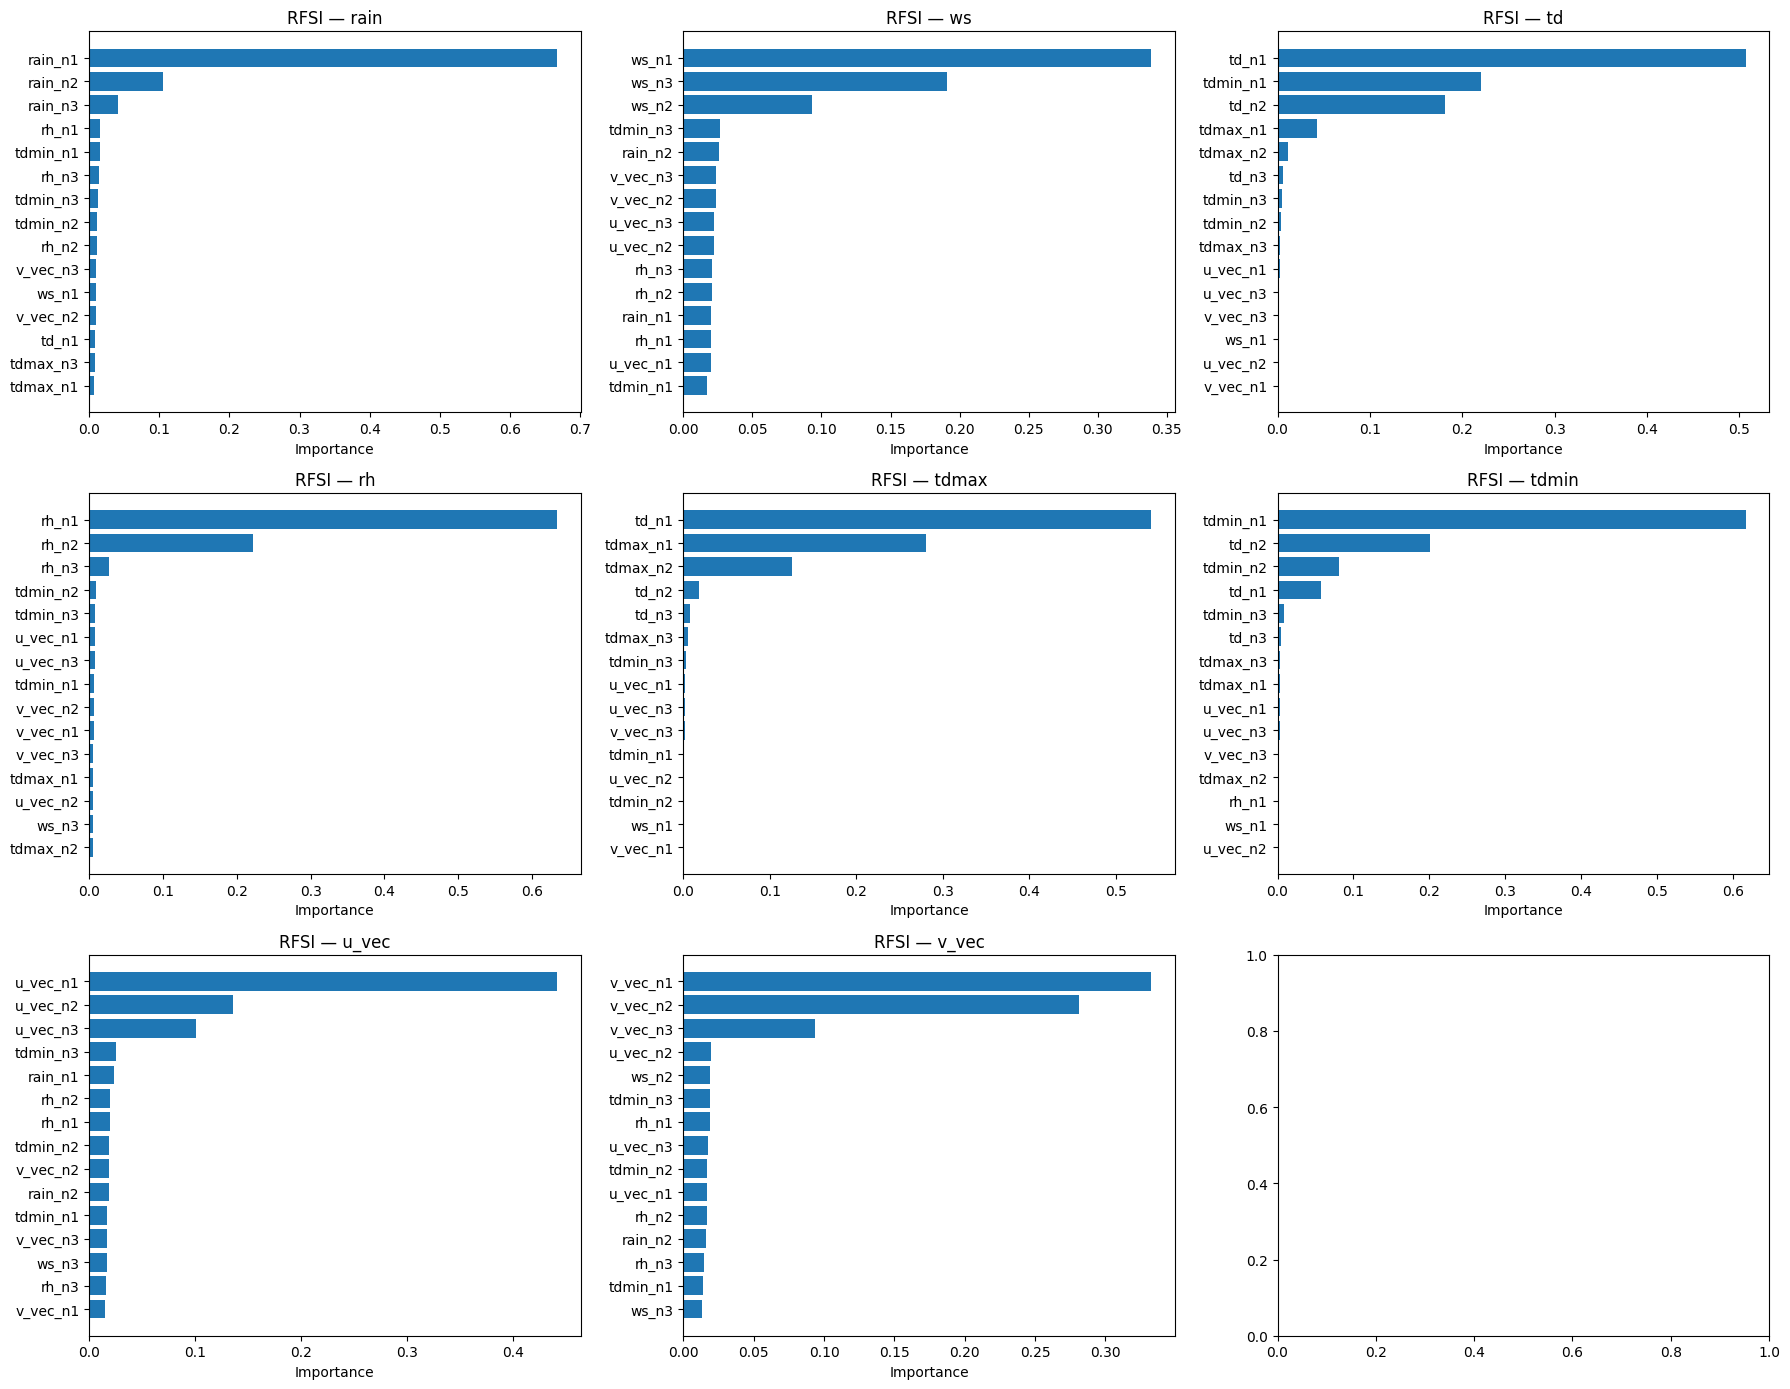

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, (feature, model) in enumerate(models.items()):
    importances = model.feature_importances_
    feature_names = X_train.columns
    sorted_idx = importances.argsort()[::-1][:15]  # top 15

    axes[i].barh(feature_names[sorted_idx][::-1], importances[sorted_idx][::-1])
    axes[i].set_title(f'RFSI — {feature}')
    axes[i].set_xlabel('Importance')

plt.tight_layout()
plt.show()


In [7]:
n1_dists = station_neighbors["neighbor_1_distance"].mean()
n2_dists = station_neighbors["neighbor_2_distance"].mean()
n3_dists = station_neighbors["neighbor_3_distance"].mean()

print(f"Mean of distance to neighbor 1: {n1_dists}\nMean of distance to neighbor 2: {n2_dists}\nMean of distance to neighbor 3: {n3_dists}")

Mean of distance to neighbor 1: 13.148224263812258
Mean of distance to neighbor 2: 18.83426955658718
Mean of distance to neighbor 3: 27.760614607554906


Those results explain why neighbor the feature importances show the neighbors ordered from 1 to 3 (most to least important), neighbor 3 is always farther away.